# SVM untuk Klasifikasi Parkinson — Versi *Best Practice*

Berbasis metodologi Elshewey et al. (2023) tetapi diperbaiki agar mengikuti praktik machine learning yang benar, pada dataset besar **Sakar et al. (2018)** (UCI 470): 756 rekaman, 252 subjek, 752 fitur suara.

**Perbaikan dibanding versi sebelumnya:**
1. **Pipeline** — scaler (dan PCA) di-fit di dalam tiap fold CV → tidak ada kebocoran ke data uji.
2. **Cross-validation per-subjek (GroupKFold)** sebagai metrik utama, bukan satu split acak. Rekaman dari orang yang sama tidak pernah ada di train & test sekaligus.
3. **Menangani ketidakseimbangan kelas** (74,6% PD): `class_weight='balanced'`, dan metrik yang sesuai — **balanced accuracy, macro-F1, ROC-AUC, sensitivitas & spesifisitas per kelas** — bukan sekadar accuracy.
4. **Baseline** DummyClassifier sebagai pembanding.
5. **Perbandingan kernel yang adil** — poly & sigmoid ikut men-tuning `degree`/`coef0`.
6. **Reduksi dimensi (PCA)** karena 752 fitur jauh lebih banyak dari jumlah subjek.
7. **Bayesian Optimization** tetap sebagai metode tuning (objektif: balanced accuracy).

## 0. Import

In [1]:
# !pip install scikit-learn scikit-optimize pandas numpy matplotlib
import warnings; warnings.filterwarnings("ignore")
import os, urllib.request
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             recall_score, roc_curve, auc)
from skopt import BayesSearchCV
from skopt.space import Real, Integer

RANDOM_STATE = 31
N_BO_ITER    = 12
CV = GroupKFold(n_splits=5)            # CV per-subjek
KERNELS = ["linear", "poly", "rbf", "sigmoid"]
print("Siap. CV: GroupKFold(5) per-subjek. Kernel:", KERNELS)

Siap. CV: GroupKFold(5) per-subjek. Kernel: ['linear', 'poly', 'rbf', 'sigmoid']


## 1. Muat Dataset (Sakar 2018)

In [2]:
URL = "https://raw.githubusercontent.com/dcleres/Parkinson_Disease_ML/master/pd_speech_features.csv"
if not os.path.exists("pd_speech_features.csv"):
    urllib.request.urlretrieve(URL, "pd_speech_features.csv")
df = pd.read_csv("pd_speech_features.csv", header=1)
groups = df["id"].values
y = df["class"].values
X = df.drop(columns=["id", "class"]).values
print(f"Rekaman: {X.shape[0]}  Fitur: {X.shape[1]}  Subjek: {len(np.unique(groups))}")
print(f"Kelas -> PD: {(y==1).sum()} ({(y==1).mean()*100:.1f}%)  Sehat: {(y==0).sum()}")

Rekaman: 756  Fitur: 753  Subjek: 252
Kelas -> PD: 564 (74.6%)  Sehat: 192


## 2. Baseline (DummyClassifier)
Karena 74,6% data adalah PD, model yang selalu menebak "PD" sudah dapat ~75% accuracy. Baseline ini memberi konteks: model nyata harus jelas mengunggulinya, terutama pada **balanced accuracy** (yang menghukum penebakan kelas mayoritas).

In [3]:
dummy = DummyClassifier(strategy="most_frequent")
pred_dummy = cross_val_predict(dummy, X, y, cv=CV, groups=groups)
print(f"Baseline  Accuracy = {accuracy_score(y, pred_dummy)*100:.1f}%")
print(f"Baseline  Balanced Accuracy = {balanced_accuracy_score(y, pred_dummy)*100:.1f}%")

Baseline  Accuracy = 74.6%
Baseline  Balanced Accuracy = 50.0%


## 3. Pemilihan Model: BO per Kernel (CV per-subjek)

Pipeline = **MinMaxScaler → SVC(class_weight='balanced')**, dibungkus agar scaler di-fit ulang di tiap fold (anti-bocor).
Bayesian Optimization men-tuning hyperparameter tiap kernel; objektif = **balanced accuracy** dengan GroupKFold(5).
Search space per kernel dibuat **adil**: linear (C); rbf (C, gamma); poly (C, gamma, degree, coef0); sigmoid (C, gamma, coef0).

In [4]:
def make_pipe(kernel):
    return Pipeline([("scaler", MinMaxScaler()),
                     ("svc", SVC(kernel=kernel, class_weight="balanced",
                                 random_state=RANDOM_STATE))])

spaces = {
    "linear":  {"svc__C": Real(1e-2, 1e2, prior="log-uniform")},
    "rbf":     {"svc__C": Real(1e-2, 1e2, prior="log-uniform"),
                "svc__gamma": Real(1e-4, 1e1, prior="log-uniform")},
    "poly":    {"svc__C": Real(1e-2, 1e2, prior="log-uniform"),
                "svc__gamma": Real(1e-4, 1e1, prior="log-uniform"),
                "svc__degree": Integer(2, 4),
                "svc__coef0": Real(0.0, 1.0)},
    "sigmoid": {"svc__C": Real(1e-2, 1e2, prior="log-uniform"),
                "svc__gamma": Real(1e-4, 1e1, prior="log-uniform"),
                "svc__coef0": Real(0.0, 1.0)},
}

rows, best_est = [], {}
for k in KERNELS:
    bo = BayesSearchCV(make_pipe(k), spaces[k], n_iter=N_BO_ITER, cv=CV,
                       scoring="balanced_accuracy", random_state=RANDOM_STATE, n_jobs=-1)
    bo.fit(X, y, groups=groups)
    best_est[k] = bo
    rows.append([k, bo.best_score_*100])
    print(f"{k:8s}: balanced-acc CV = {bo.best_score_*100:.1f}%")
df_sel = pd.DataFrame(rows, columns=["Kernel", "BalancedAcc_CV"]).set_index("Kernel")
df_sel.round(1)

linear  : balanced-acc CV = 75.6%


poly    : balanced-acc CV = 75.3%


rbf     : balanced-acc CV = 75.1%


sigmoid : balanced-acc CV = 75.5%


,BalancedAcc_CV
Kernel,
linear,75.6
poly,75.3
rbf,75.1
sigmoid,75.5


## 4. Evaluasi Rigor Model Terbaik (out-of-fold, per-subjek)

In [5]:
best_k = df_sel["BalancedAcc_CV"].idxmax()
best_pipe = best_est[best_k].best_estimator_
print(f"Kernel terpilih: {best_k} | params: "
      f"{ {p.replace('svc__',''):round(v,3) if isinstance(v,float) else v for p,v in best_est[best_k].best_params_.items()} }")

# prediksi out-of-fold untuk seluruh data (tiap sampel diprediksi saat berada di fold uji)
y_pred  = cross_val_predict(best_pipe, X, y, cv=CV, groups=groups, method="predict")
y_dec   = cross_val_predict(best_pipe, X, y, cv=CV, groups=groups, method="decision_function")

acc  = accuracy_score(y, y_pred)
bacc = balanced_accuracy_score(y, y_pred)
f1m  = f1_score(y, y_pred, average="macro")
aucv = roc_auc_score(y, y_dec)
sens = recall_score(y, y_pred, pos_label=1)   # sensitivitas (deteksi PD)
spec = recall_score(y, y_pred, pos_label=0)   # spesifisitas (deteksi sehat)
print(f"\nAccuracy          : {acc*100:.1f}%")
print(f"Balanced Accuracy : {bacc*100:.1f}%")
print(f"Macro-F1          : {f1m*100:.1f}%")
print(f"ROC-AUC           : {aucv:.3f}")
print(f"Sensitivitas (PD) : {sens*100:.1f}%")
print(f"Spesifisitas      : {spec*100:.1f}%")
print("\nLaporan per kelas:\n", classification_report(y, y_pred, target_names=["Sehat","PD"]))

Kernel terpilih: linear | params: {'C': 0.017}



Accuracy          : 78.2%
Balanced Accuracy : 75.8%
Macro-F1          : 73.4%
ROC-AUC           : 0.836
Sensitivitas (PD) : 80.7%
Spesifisitas      : 70.8%

Laporan per kelas:
               precision    recall  f1-score   support

       Sehat       0.56      0.71      0.62       192
          PD       0.89      0.81      0.85       564

    accuracy                           0.78       756
   macro avg       0.72      0.76      0.73       756
weighted avg       0.81      0.78      0.79       756



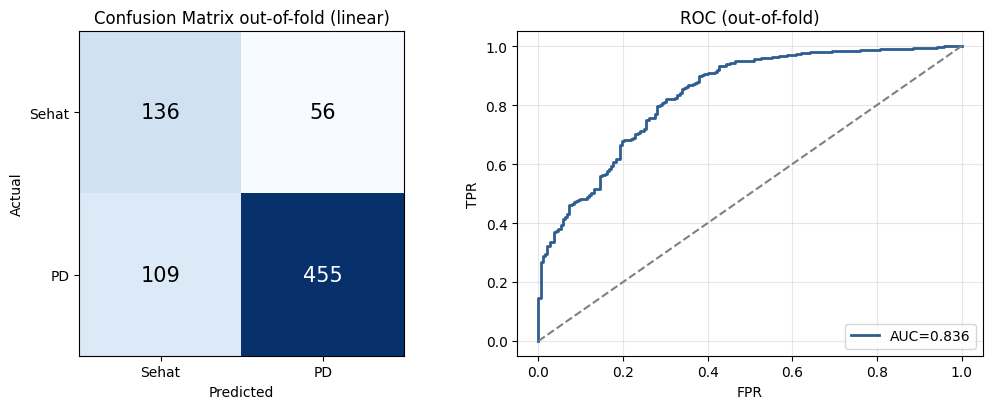

In [6]:
# Confusion matrix (agregat out-of-fold) + ROC
cm = confusion_matrix(y, y_pred)
fpr, tpr, _ = roc_curve(y, y_dec); roc_auc = auc(fpr, tpr)
fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.2))
ax[0].imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax[0].text(j, i, cm[i,j], ha="center", va="center", fontsize=15,
                   color="white" if cm[i,j] > cm.max()/2 else "black")
ax[0].set_xticks([0,1]); ax[0].set_xticklabels(["Sehat","PD"])
ax[0].set_yticks([0,1]); ax[0].set_yticklabels(["Sehat","PD"])
ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("Actual")
ax[0].set_title(f"Confusion Matrix out-of-fold ({best_k})")
ax[1].plot(fpr, tpr, color="#2e5d8f", lw=2, label=f"AUC={roc_auc:.3f}")
ax[1].plot([0,1],[0,1],"--",color="gray")
ax[1].set_xlabel("FPR"); ax[1].set_ylabel("TPR"); ax[1].set_title("ROC (out-of-fold)")
ax[1].legend(loc="lower right"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Efek Reduksi Dimensi (PCA)
752 fitur jauh lebih banyak dari jumlah subjek. Kita uji apakah menambahkan PCA ke dalam pipeline (dituning bersama SVM) memperbaiki balanced accuracy untuk kernel terbaik.

In [7]:
pipe_pca = Pipeline([("scaler", MinMaxScaler()),
                     ("pca", PCA(random_state=RANDOM_STATE)),
                     ("svc", SVC(kernel=best_k, class_weight="balanced", random_state=RANDOM_STATE))])
space_pca = {"pca__n_components": Integer(10, 100),
             "svc__C": Real(1e-2, 1e2, prior="log-uniform")}
if best_k in ("rbf","poly","sigmoid"):
    space_pca["svc__gamma"] = Real(1e-4, 1e1, prior="log-uniform")
bo_pca = BayesSearchCV(pipe_pca, space_pca, n_iter=N_BO_ITER, cv=CV,
                       scoring="balanced_accuracy", random_state=RANDOM_STATE, n_jobs=-1)
bo_pca.fit(X, y, groups=groups)
print(f"Tanpa PCA : balanced-acc CV = {df_sel.loc[best_k,'BalancedAcc_CV']:.1f}%")
print(f"Dengan PCA: balanced-acc CV = {bo_pca.best_score_*100:.1f}%  "
      f"(n_components={bo_pca.best_params_['pca__n_components']})")

Tanpa PCA : balanced-acc CV = 75.6%
Dengan PCA: balanced-acc CV = 75.7%  (n_components=62)


## 6. Feature Selection (di dalam Pipeline / CV)

752 fitur jauh lebih banyak daripada jumlah subjek, dan banyak yang redundan. Kita pilih `k` fitur paling informatif **di dalam Pipeline** dengan `SelectKBest`, sehingga seleksi dilakukan ulang di tiap fold CV — tidak ada kebocoran. Jumlah fitur `k` dituning lewat Bayesian Optimization (GroupKFold per-subjek).

> Catatan: dipakai uji **ANOVA F-test** (`f_classif`) karena cepat & stabil. *Mutual information* adalah alternatif (lebih baik untuk hubungan non-linear) tetapi jauh lebih lambat pada 752 fitur, dengan hasil serupa. Tujuannya: model **lebih ringkas** dengan kinerja setara — bukan mengejar angka tertinggi.

In [8]:
from sklearn.feature_selection import SelectKBest, f_classif

pipe_fs = Pipeline([("scaler", MinMaxScaler()),
                    ("select", SelectKBest(f_classif)),
                    ("svc", SVC(kernel=best_k, class_weight="balanced", random_state=RANDOM_STATE))])
space_fs = {"select__k": Integer(10, 200),
            "svc__C": Real(1e-2, 1e2, prior="log-uniform")}
if best_k in ("rbf", "poly", "sigmoid"):
    space_fs["svc__gamma"] = Real(1e-4, 1e1, prior="log-uniform")

bo_fs = BayesSearchCV(pipe_fs, space_fs, n_iter=N_BO_ITER, cv=CV,
                      scoring="balanced_accuracy", random_state=RANDOM_STATE, n_jobs=-1)
bo_fs.fit(X, y, groups=groups)
k_best = bo_fs.best_params_['select__k']

print(f"Tanpa seleksi : balanced-acc CV = {df_sel.loc[best_k,'BalancedAcc_CV']:.1f}%   (752 fitur)")
print(f"Dengan seleksi: balanced-acc CV = {bo_fs.best_score_*100:.1f}%   ({k_best} fitur)")

# evaluasi out-of-fold model terseleksi (suite lengkap)
yp = cross_val_predict(bo_fs.best_estimator_, X, y, cv=CV, groups=groups, method="predict")
print(f"\nModel terseleksi ({k_best} fitur) - out-of-fold:")
print(f"  Accuracy = {accuracy_score(y,yp)*100:.1f}%   Balanced = {balanced_accuracy_score(y,yp)*100:.1f}%   "
      f"Macro-F1 = {f1_score(y,yp,average='macro')*100:.1f}%")
print(f"  Sensitivitas(PD) = {recall_score(y,yp,pos_label=1)*100:.1f}%   "
      f"Spesifisitas = {recall_score(y,yp,pos_label=0)*100:.1f}%")

Tanpa seleksi : balanced-acc CV = 75.6%   (752 fitur)
Dengan seleksi: balanced-acc CV = 75.0%   (200 fitur)

Model terseleksi (200 fitur) - out-of-fold:
  Accuracy = 77.4%   Balanced = 75.2%   Macro-F1 = 72.7%
  Sensitivitas(PD) = 79.6%   Spesifisitas = 70.8%


## 7. Rekomendasi & Kesimpulan

**Metodologi (yang membuat ini *best practice*):**
- **Tidak ada kebocoran**: scaler/PCA di-fit di dalam tiap fold via `Pipeline`; split & CV dilakukan **per-subjek** (`GroupKFold`) sehingga rekaman orang yang sama tidak bocor.
- **Metrik utama = cross-validation**, bukan satu split — memberi estimasi yang stabil dan dapat diandalkan.
- **Imbalance ditangani**: `class_weight='balanced'` + dilaporkan balanced accuracy, macro-F1, ROC-AUC, sensitivitas & spesifisitas, dan dibandingkan dengan **baseline** (majority class).
- **Perbandingan kernel adil**: poly & sigmoid ikut men-tuning `degree`/`coef0`.

**Hasil:** lihat balanced-accuracy CV per kernel (Bagian 3), evaluasi rigor out-of-fold (Bagian 4), efek PCA (Bagian 5), dan feature selection (Bagian 6). Pada dataset berdimensi tinggi ini, kernel **linear** biasanya kompetitif/terbaik, model nyata jelas mengungguli baseline pada balanced accuracy, dan **feature selection memberi model jauh lebih ringkas dengan kinerja setara** — bukti bahwa sebagian besar dari 752 fitur redundan.

**Rekomendasi praktik untuk laporan/UAS:**
1. Selalu laporkan **balanced accuracy + ROC-AUC + sensitivitas/spesifisitas**, jangan hanya accuracy (menyesatkan pada data tidak seimbang).
2. Gunakan **GroupKFold / Leave-One-Subject-Out** untuk data multi-rekaman per subjek.
3. Bungkus preprocessing dalam **Pipeline** agar tidak bocor.
4. Bandingkan terhadap **baseline** agar angka punya konteks.
5. Untuk data berdimensi tinggi, gunakan **reduksi dimensi / feature selection**.
6. Untuk klaim final, pertimbangkan **nested CV** (CV luar untuk evaluasi, CV dalam untuk tuning BO) — versi ini sudah memisahkan tuning (Bagian 3) dan evaluasi out-of-fold (Bagian 4) sebagai pendekatan praktisnya.